# Gas-Limit Event Study: Data vs Execution Share

This notebook is the data/execution analogue of Maria's state/rest gas-limit
analysis. Gas-limit increases are common blockspace-price shocks, not
calldata-only shocks. The question is whether calldata/data expands more than
execution when blockspace gets cheaper.

Inside the current-rule non-state bucket:

$$
\text{rest} = \text{data} + \text{execution}
$$

$$
\alpha_{\text{data}|\text{rest}}
=
\frac{\text{data}}{\text{data} + \text{execution}}
$$

If $\alpha_{\text{data}|\text{rest}}$ rises when base fee falls, then calldata/data
is more price-sensitive than execution. The implied share elasticity is:

$$
\eta_{\text{data}}
\approx
-\frac{
  \Delta \operatorname{logit}(\alpha_{\text{data}|\text{rest}})
}{
  \Delta \log(\text{base fee})
}
$$

This is an H0 historical analysis. It does not use EIP-8037 state gas, G0
Glamsterdam gas, BALs, or EIP-7999 bandwidth pricing. It is a second prior for
`eta_data`, complementary to the EIP-7623 calldata price-shock notebook.


## Method

The structure mirrors Maria's `0.7-resource_price_elasticity_v2.ipynb`:

1. Pull daily block/base-fee/gas-limit data.
2. Pull daily transaction body gas and calldata gas.
3. Remove a current-rule state proxy from the denominator.
4. Estimate how `data_share_rest` changes around gas-limit increases.

The state-cleaning term is intentionally a **daily inventory-delta proxy**, not
the exact RPC-calibrated state creation. It follows the
broad daily method and is cheap enough for a full 2025 panel:

$$
\begin{aligned}
\text{state\_inventory\_delta\_gas\_proxy}
=&\ \max(0, \Delta\text{account\_bytes}) \cdot \frac{25{,}000}{112} \\
&+ \max(0, \Delta\text{storage\_bytes}) \cdot \frac{20{,}000}{32} \\
&+ \max(0, \Delta\text{contract\_code\_bytes}) \cdot 200
\end{aligned}
$$



## Parameters And Setup


In [1]:
import os
from pathlib import Path
import sys

import clickhouse_connect
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
from dotenv import load_dotenv

try:
    from scipy import stats
    from statsmodels.tsa.ardl import ardl_select_order
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAVE_STATSMODELS = True
except Exception as exc:
    HAVE_STATSMODELS = False
    STATSMODELS_IMPORT_ERROR = exc

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

pd.options.display.float_format = "{:,.6f}".format

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
CLICKHOUSE_CBT_HOST = os.environ.get("CLICKHOUSE_CBT_HOST", "clickhouse-cbt.xatu.ethpandaops.io")
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)
cbt_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_CBT_HOST,
    port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

NETWORK = "mainnet"
START_TS = "2025-01-01 00:00:00"
END_TS = "2026-01-05 00:00:00"
PECTRA_TS = "2025-05-07 10:05:00"

EVENTS = [
    {"event": "30_to_36", "date": pd.Timestamp("2025-02-04"), "old_limit_mgas": 30, "new_limit_mgas": 36},
    {"event": "36_to_45", "date": pd.Timestamp("2025-07-21"), "old_limit_mgas": 36, "new_limit_mgas": 45},
    {"event": "45_to_60", "date": pd.Timestamp("2025-11-25"), "old_limit_mgas": 45, "new_limit_mgas": 60},
]

WINDOW_DAYS = 35
EXCLUDE_DAYS_AROUND_EVENT = 3
WRITE_CSV = True

DAILY_RAW_CSV = DATA_DIR / "gas_limit_data_share_daily_raw_2025-01-01_2026-01-05.csv"
STATE_BOUNDARY_CSV = DATA_DIR / "gas_limit_data_share_state_boundaries_2025-01-01_2026-01-05.csv"
DAILY_CSV = DATA_DIR / "gas_limit_data_share_daily_2025-01-01_2026-01-05.csv"
EVENT_CSV = DATA_DIR / "gas_limit_data_share_event_estimates_2025.csv"
REGIME_CSV = DATA_DIR / "gas_limit_data_share_regime_estimates_2025.csv"
ARDL_CSV = DATA_DIR / "gas_limit_data_share_ardl_2025.csv"
SUMMARY_CSV = DATA_DIR / "gas_limit_data_share_summary_2025.csv"

print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)
print("cbt", CLICKHOUSE_CBT_HOST, cbt_client.query("SELECT version()").result_rows)


raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]
cbt clickhouse-cbt.xatu.ethpandaops.io [('26.2.5.45',)]


## Helpers


In [2]:
def load_or_query_csv(path: Path, query_fn, *, refresh: bool = False) -> pd.DataFrame:
    if path.exists() and not refresh:
        print("loading cached", path)
        return pd.read_csv(path)
    out = query_fn()
    if WRITE_CSV:
        out.to_csv(path, index=False)
        print("wrote", path)
    return out


def logit(x: float) -> float:
    x = float(x)
    if x <= 0 or x >= 1 or not np.isfinite(x):
        return np.nan
    return float(np.log(x / (1 - x)))


def assigned_limit_mgas(date: pd.Timestamp) -> float:
    if date < pd.Timestamp("2025-02-04"):
        return 30.0
    if date < pd.Timestamp("2025-07-21"):
        return 36.0
    if date < pd.Timestamp("2025-11-25"):
        return 45.0
    return 60.0


def safe_eta(pre_share: float, post_share: float, pre_base_fee: float, post_base_fee: float) -> float:
    if not all(np.isfinite(v) for v in [pre_share, post_share, pre_base_fee, post_base_fee]):
        return np.nan
    if pre_base_fee <= 0 or post_base_fee <= 0:
        return np.nan
    denominator = np.log(post_base_fee / pre_base_fee)
    if denominator == 0:
        return np.nan
    return -((logit(post_share) - logit(pre_share)) / denominator)


def pooled_share(frame: pd.DataFrame) -> float:
    data = float(frame["data_gas_current"].sum())
    execution = float(frame["execution_gas_state_cleaned"].clip(lower=0).sum())
    return data / (data + execution) if (data + execution) > 0 else np.nan


## Block Bounds


In [3]:
bounds = raw_client.query_df(
    """
    SELECT
        min(block_number) AS min_block,
        max(block_number) AS max_block,
        count() AS block_count
    FROM default.canonical_execution_block FINAL
    WHERE meta_network_name = {network:String}
      AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
      AND block_date_time < parseDateTime64BestEffort({end_ts:String})
    """,
    parameters={"network": NETWORK, "start_ts": START_TS, "end_ts": END_TS},
)
MIN_BLOCK = int(bounds.loc[0, "min_block"])
MAX_BLOCK = int(bounds.loc[0, "max_block"])
bounds


,min_block,max_block,block_count
0,21525891,24164738,2638848


## Daily Block And Transaction Accounting

This pulls the historical block/common-price side and the calldata/data side from
raw Xatu. The data gas proxy is:

- pre-Pectra: standard calldata gas (`4/16`);
- post-Pectra: standard calldata gas for non-floor-bound transactions, and the
  EIP-7623 floor branch for floor-bound transactions.

That is a proxy for historically charged calldata/data pressure, not a 7976 or
7999 metric.


In [4]:
def query_daily_raw():
    return raw_client.query_df(
        """
        WITH
            blocks AS
            (
                SELECT
                    block_number,
                    block_date_time,
                    toDate(block_date_time) AS date,
                    gas_used AS block_gas_used_raw,
                    gas_limit AS block_gas_limit,
                    base_fee_per_gas AS base_fee_per_gas
                FROM default.canonical_execution_block FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                  AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
                  AND block_date_time < parseDateTime64BestEffort({end_ts:String})
            ),
            tx AS
            (
                SELECT
                    block_number,
                    count() AS tx_count,
                    sum(gas_used) AS receipt_gas_used,
                    sum(greatest(toInt64(gas_used) - 21000, 0)) AS receipt_body_gas,
                    sum(toUInt64(n_input_bytes)) AS calldata_bytes,
                    sum(toUInt64(n_input_zero_bytes)) AS calldata_zero_bytes,
                    sum(toUInt64(n_input_nonzero_bytes)) AS calldata_nonzero_bytes,
                    sum(toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))) AS standard_calldata_gas,
                    sum(
                        if(
                            greatest(toInt64(gas_used) - 21000, 0) <= toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))
                            AND (n_input_zero_bytes + n_input_nonzero_bytes) > 0,
                            toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)),
                            toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))
                        )
                    ) AS post_7623_data_gas_proxy,
                    countIf(
                        greatest(toInt64(gas_used) - 21000, 0) <= toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes))
                        AND (n_input_zero_bytes + n_input_nonzero_bytes) > 0
                    ) AS floor_bound_7623_proxy_txs
                FROM default.canonical_execution_transaction FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                GROUP BY block_number
            ),
            by_block AS
            (
                SELECT
                    b.*,
                    ifNull(t.tx_count, 0) AS tx_count,
                    ifNull(t.receipt_gas_used, 0) AS receipt_gas_used,
                    ifNull(t.receipt_body_gas, 0) AS receipt_body_gas,
                    ifNull(t.calldata_bytes, 0) AS calldata_bytes,
                    ifNull(t.calldata_zero_bytes, 0) AS calldata_zero_bytes,
                    ifNull(t.calldata_nonzero_bytes, 0) AS calldata_nonzero_bytes,
                    ifNull(t.standard_calldata_gas, 0) AS standard_calldata_gas,
                    if(
                        b.block_date_time >= parseDateTime64BestEffort({pectra_ts:String}),
                        ifNull(t.post_7623_data_gas_proxy, 0),
                        ifNull(t.standard_calldata_gas, 0)
                    ) AS data_gas_current,
                    if(
                        b.block_date_time >= parseDateTime64BestEffort({pectra_ts:String}),
                        ifNull(t.post_7623_data_gas_proxy, 0) - ifNull(t.standard_calldata_gas, 0),
                        0
                    ) AS eip7623_data_uplift_proxy,
                    if(
                        b.block_date_time >= parseDateTime64BestEffort({pectra_ts:String}),
                        ifNull(t.floor_bound_7623_proxy_txs, 0),
                        0
                    ) AS floor_bound_7623_proxy_txs
                FROM blocks AS b
                LEFT JOIN tx AS t USING block_number
            )
        SELECT
            date,
            min(block_date_time) AS first_block_time,
            max(block_date_time) AS last_block_time,
            count() AS block_count,
            min(block_number) AS min_block,
            max(block_number) AS max_block,
            sum(block_gas_used_raw) AS block_gas_used,
            sum(receipt_gas_used) AS receipt_gas_used,
            sum(receipt_body_gas) AS receipt_body_gas,
            sum(tx_count) AS tx_count,
            avg(toFloat64(block_gas_limit)) AS mean_gas_limit,
            quantileExact(0.5)(block_gas_limit) AS median_gas_limit,
            avg(toFloat64(base_fee_per_gas)) AS mean_base_fee_per_gas,
            quantileExact(0.5)(base_fee_per_gas) AS median_base_fee_per_gas,
            sum(toFloat64(base_fee_per_gas) * toFloat64(block_gas_used_raw)) / nullIf(sum(toFloat64(block_gas_used_raw)), 0) AS gas_weighted_base_fee_per_gas,
            sum(calldata_bytes) AS calldata_bytes,
            sum(calldata_zero_bytes) AS calldata_zero_bytes,
            sum(calldata_nonzero_bytes) AS calldata_nonzero_bytes,
            sum(standard_calldata_gas) AS standard_calldata_gas,
            sum(data_gas_current) AS data_gas_current,
            sum(eip7623_data_uplift_proxy) AS eip7623_data_uplift_proxy,
            sum(floor_bound_7623_proxy_txs) AS floor_bound_7623_proxy_txs
        FROM by_block
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "pectra_ts": PECTRA_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 1200},
    )


daily_raw = load_or_query_csv(DAILY_RAW_CSV, query_daily_raw)
daily_raw["date"] = pd.to_datetime(daily_raw["date"])
for col in ["first_block_time", "last_block_time"]:
    daily_raw[col] = pd.to_datetime(daily_raw[col])
num_cols = [c for c in daily_raw.columns if c not in ["date", "first_block_time", "last_block_time"]]
daily_raw[num_cols] = daily_raw[num_cols].apply(pd.to_numeric, errors="coerce")
daily_raw.head()


wrote /Users/william/PycharmProjects/eip-7999-research/data/gas_limit_data_share_daily_raw_2025-01-01_2026-01-05.csv


,date,first_block_time,last_block_time,block_count,min_block,max_block,block_gas_used,receipt_gas_used,receipt_body_gas,tx_count,...,mean_base_fee_per_gas,median_base_fee_per_gas,gas_weighted_base_fee_per_gas,calldata_bytes,calldata_zero_bytes,calldata_nonzero_bytes,standard_calldata_gas,data_gas_current,eip7623_data_uplift_proxy,floor_bound_7623_proxy_txs
0,2025-01-01,2025-01-01 00:00:11,2025-01-01 23:59:59,7168,21525891,21533058,108771628808,108771628808,86914660808,1040808,...,"16,523,872,301.910715",8144899401,"16,365,132,963.354355",342686089,234319074,108367015,2671148536,2671148536,0,0
1,2025-01-02,2025-01-02 00:00:11,2025-01-02 23:59:59,7174,21533059,21540232,108479938127,108479938127,85664908127,1086430,...,"21,707,916,992.806522",13072397005,"21,517,486,596.678066",327070836,221464848,105605988,2575555200,2575555200,0,0
2,2025-01-03,2025-01-03 00:00:11,2025-01-03 23:59:59,7164,21540233,21547396,108412109486,108412109486,82454849486,1236060,...,"11,199,641,772.198074",8721016906,"11,106,631,242.904160",370372949,247991812,122381137,2950065440,2950065440,0,0
3,2025-01-04,2025-01-04 00:00:11,2025-01-04 23:59:47,7160,21547397,21554556,108330636794,108330636794,83935146794,1161690,...,"8,694,224,021.009777",6430676260,"8,621,664,682.142258",371229488,247514293,123715195,2969500292,2969500292,0,0
4,2025-01-05,2025-01-05 00:00:11,2025-01-05 23:59:59,7153,21554557,21561709,108270391071,108270391071,84271423071,1142808,...,"7,066,337,246.751014",6653676098,"7,005,255,623.356413",372371776,252743158,119628618,2925030520,2925030520,0,0


## Daily State Inventory Delta Proxy

To keep the full-year notebook runnable, the state proxy comes from CBT state
size at the first and last block of each day. This is a net inventory-delta proxy
rather than exact gross state creation. It is good enough to remove the largest
state-growth component from the data/execution denominator and see whether the
share signal survives.


In [5]:
def query_state_boundaries():
    blocks = sorted(set(daily_raw["min_block"].astype(int)).union(daily_raw["max_block"].astype(int)))
    return cbt_client.query_df(
        """
        SELECT
            block_number,
            argMax(account_bytes, updated_date_time) AS account_bytes,
            argMax(contract_code_bytes, updated_date_time) AS contract_code_bytes,
            argMax(storage_bytes, updated_date_time) AS storage_bytes
        FROM mainnet.int_execution_state_size_by_block
        WHERE block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ORDER BY block_number
        """,
        parameters={"blocks": blocks},
        settings={"max_execution_time": 300},
    )

state_boundaries = load_or_query_csv(STATE_BOUNDARY_CSV, query_state_boundaries)
state_boundaries["block_number"] = state_boundaries["block_number"].astype(int)
for col in ["account_bytes", "contract_code_bytes", "storage_bytes"]:
    state_boundaries[col] = pd.to_numeric(state_boundaries[col], errors="coerce")

starts = state_boundaries.rename(
    columns={
        "block_number": "min_block",
        "account_bytes": "start_account_bytes",
        "contract_code_bytes": "start_contract_code_bytes",
        "storage_bytes": "start_storage_bytes",
    }
)
ends = state_boundaries.rename(
    columns={
        "block_number": "max_block",
        "account_bytes": "end_account_bytes",
        "contract_code_bytes": "end_contract_code_bytes",
        "storage_bytes": "end_storage_bytes",
    }
)

daily = daily_raw.merge(starts, on="min_block", how="left").merge(ends, on="max_block", how="left")
for name in ["account_bytes", "contract_code_bytes", "storage_bytes"]:
    daily[f"{name}_delta"] = daily[f"end_{name}"] - daily[f"start_{name}"]
    daily[f"{name}_delta_positive"] = daily[f"{name}_delta"].clip(lower=0)

daily["gas_limit_mgas"] = daily["date"].map(assigned_limit_mgas)
daily["current_state_inventory_delta_gas_proxy"] = (
    daily["account_bytes_delta_positive"] * (25_000 / 112)
    + daily["storage_bytes_delta_positive"] * (20_000 / 32)
    + daily["contract_code_bytes_delta_positive"] * 200
)
daily["execution_gas_state_cleaned"] = (
    daily["receipt_body_gas"]
    - daily["data_gas_current"]
    - daily["current_state_inventory_delta_gas_proxy"]
)
daily["execution_gas_state_cleaned_clipped"] = daily["execution_gas_state_cleaned"].clip(lower=0)
daily["data_share_rest"] = daily["data_gas_current"] / (
    daily["data_gas_current"] + daily["execution_gas_state_cleaned_clipped"]
).replace(0, np.nan)
daily["logit_data_share_rest"] = daily["data_share_rest"].map(logit)
daily["base_fee_log_diff"] = np.log(daily["median_base_fee_per_gas"]).diff()
daily["logit_data_share_diff"] = daily["logit_data_share_rest"].diff()
daily["data_gas_log_diff"] = np.log(daily["data_gas_current"].replace(0, np.nan)).diff()
daily["execution_gas_log_diff"] = np.log(daily["execution_gas_state_cleaned_clipped"].replace(0, np.nan)).diff()
daily["state_removed_share_of_body"] = daily["current_state_inventory_delta_gas_proxy"] / daily["receipt_body_gas"].replace(0, np.nan)
daily["data_gas_per_block"] = daily["data_gas_current"] / daily["block_count"].replace(0, np.nan)
daily["execution_gas_per_block"] = daily["execution_gas_state_cleaned_clipped"] / daily["block_count"].replace(0, np.nan)
daily["state_proxy_gas_per_block"] = daily["current_state_inventory_delta_gas_proxy"] / daily["block_count"].replace(0, np.nan)

if WRITE_CSV:
    daily.to_csv(DAILY_CSV, index=False)

daily[["date", "block_count", "median_base_fee_per_gas", "gas_limit_mgas", "data_share_rest", "data_gas_per_block", "execution_gas_per_block", "state_proxy_gas_per_block"]].head()


wrote /Users/william/PycharmProjects/eip-7999-research/data/gas_limit_data_share_state_boundaries_2025-01-01_2026-01-05.csv


,date,block_count,median_base_fee_per_gas,gas_limit_mgas,data_share_rest,data_gas_per_block,execution_gas_per_block,state_proxy_gas_per_block
0,2025-01-01,7168,8144899401,30.000000,0.057582,"372,649.070312","6,098,952.979592","5,653,769.156569"
1,2025-01-02,7174,13072397005,30.000000,0.062902,"359,012.433789","5,348,451.936338","6,233,559.901828"
2,2025-01-03,7164,8721016906,30.000000,0.044861,"411,790.262423","8,767,441.505833","2,330,378.712760"
3,2025-01-04,7160,6430676260,30.000000,0.043318,"414,734.677654","9,159,420.923813","2,148,630.263617"
4,2025-01-05,7153,6653676098,30.000000,0.042686,"408,923.601286","9,170,840.951739","2,201,505.273761"


## Sanity Checks


In [6]:
sanity = pd.DataFrame([
    {
        "days": len(daily),
        "start": daily["date"].min().date().isoformat(),
        "end": daily["date"].max().date().isoformat(),
        "blocks": int(daily["block_count"].sum()),
        "receipt_vs_block_gas_ratio": float(daily["receipt_gas_used"].sum() / daily["block_gas_used"].sum()),
        "negative_state_cleaned_execution_days": int((daily["execution_gas_state_cleaned"] < 0).sum()),
        "mean_data_share_rest": float(daily["data_share_rest"].mean()),
        "median_data_share_rest": float(daily["data_share_rest"].median()),
        "mean_state_removed_share_of_body": float(daily["state_removed_share_of_body"].mean()),
        "mean_eip7623_uplift_share_of_data": float(daily["eip7623_data_uplift_proxy"].sum() / daily["data_gas_current"].sum()),
    }
])
if WRITE_CSV:
    sanity.to_csv(SUMMARY_CSV, index=False)
sanity.T


,0
days,369
start,2025-01-01
end,2026-01-04
blocks,2638848
receipt_vs_block_gas_ratio,1.000000
negative_state_cleaned_execution_days,0
mean_data_share_rest,0.058343
median_data_share_rest,0.057011
mean_state_removed_share_of_body,0.290398
mean_eip7623_uplift_share_of_data,0.094957


## Regime-Level Maria-Style Estimate

This groups by gas-limit regime and compares median base fee with pooled
`data_share_rest`. It is descriptive because regimes are months apart and include
other shocks.


In [7]:
regime_rows = []
for limit, frame in daily.groupby("gas_limit_mgas", sort=True):
    regime_rows.append({
        "gas_limit_mgas": limit,
        "days": len(frame),
        "start": frame["date"].min().date().isoformat(),
        "end": frame["date"].max().date().isoformat(),
        "median_base_fee_per_gas": float(frame["median_base_fee_per_gas"].median()),
        "mean_base_fee_per_gas": float(frame["mean_base_fee_per_gas"].mean()),
        "pooled_data_share_rest": pooled_share(frame),
        "median_daily_data_share_rest": float(frame["data_share_rest"].median()),
        "data_gas_per_block": float(frame["data_gas_current"].sum() / frame["block_count"].sum()),
        "execution_gas_per_block": float(frame["execution_gas_state_cleaned_clipped"].sum() / frame["block_count"].sum()),
        "state_proxy_gas_per_block": float(frame["current_state_inventory_delta_gas_proxy"].sum() / frame["block_count"].sum()),
    })
regime = pd.DataFrame(regime_rows).sort_values("gas_limit_mgas").reset_index(drop=True)
regime["base_fee_log_change"] = np.log(regime["median_base_fee_per_gas"]).diff()
regime["data_share_logit_change"] = regime["pooled_data_share_rest"].map(logit).diff()
regime["implied_eta_data"] = -regime["data_share_logit_change"] / regime["base_fee_log_change"]
regime["event"] = [None, "30_to_36", "36_to_45", "45_to_60"][: len(regime)]
if WRITE_CSV:
    regime.to_csv(REGIME_CSV, index=False)
regime


,gas_limit_mgas,days,start,end,median_base_fee_per_gas,mean_base_fee_per_gas,pooled_data_share_rest,median_daily_data_share_rest,data_gas_per_block,execution_gas_per_block,state_proxy_gas_per_block,base_fee_log_change,data_share_logit_change,implied_eta_data,event
0,30.000000,34,2025-01-01,2025-02-03,"6,293,523,291.000000","10,477,697,676.329565",0.047561,0.047158,"423,687.476042","8,484,555.661182","2,702,272.631520",NaN,NaN,NaN,None
1,36.000000,167,2025-02-04,2025-07-20,"758,198,853.000000","1,674,053,226.492442",0.057428,0.055314,"562,047.037632","9,224,973.530168","4,587,557.781041",-2.116331,0.198923,0.093994,30_to_36
2,45.000000,127,2025-07-21,2025-11-24,"270,081,001.000000","790,744,734.402753",0.061724,0.060684,"822,885.465573","12,508,908.831706","4,703,661.983394",-1.032224,0.076705,0.074310,36_to_45
3,60.000000,41,2025-11-25,2026-01-04,"38,606,378.000000","86,448,622.624581",0.052284,0.057011,"893,979.959736","16,204,642.808724","8,305,223.539516",-1.945304,-0.175990,-0.090469,45_to_60


## Windowed Event Estimates

This is the cleaner event-style estimate. For each gas-limit increase, compare a
pre window and a post window while excluding event-adjacent days.

$$
\eta_{\text{data}}
=
-\frac{
  \operatorname{logit}(\alpha_{\text{post}})
  - \operatorname{logit}(\alpha_{\text{pre}})
}{
  \log(P_{\text{post}}) - \log(P_{\text{pre}})
}
$$

Positive $\eta_{\text{data}}$ means data share rises when base fee falls.


In [8]:
event_rows = []
for event in EVENTS:
    date = event["date"]
    pre_start = date - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_EVENT + WINDOW_DAYS)
    pre_end = date - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_EVENT)
    post_start = date + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_EVENT + 1)
    post_end = date + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_EVENT + WINDOW_DAYS)
    pre = daily[(daily["date"] >= pre_start) & (daily["date"] < pre_end)].copy()
    post = daily[(daily["date"] >= post_start) & (daily["date"] <= post_end)].copy()
    pre_share = pooled_share(pre)
    post_share = pooled_share(post)
    pre_base = float(pre["median_base_fee_per_gas"].median()) if len(pre) else np.nan
    post_base = float(post["median_base_fee_per_gas"].median()) if len(post) else np.nan
    event_rows.append({
        "event": event["event"],
        "event_date": date.date().isoformat(),
        "old_limit_mgas": event["old_limit_mgas"],
        "new_limit_mgas": event["new_limit_mgas"],
        "limit_change_pct": event["new_limit_mgas"] / event["old_limit_mgas"] - 1,
        "pre_start": pre_start.date().isoformat(),
        "pre_end_exclusive": pre_end.date().isoformat(),
        "post_start": post_start.date().isoformat(),
        "post_end_inclusive": post_end.date().isoformat(),
        "pre_days": len(pre),
        "post_days": len(post),
        "pre_base_fee_median": pre_base,
        "post_base_fee_median": post_base,
        "base_fee_log_change": np.log(post_base / pre_base) if pre_base > 0 and post_base > 0 else np.nan,
        "pre_data_share_rest": pre_share,
        "post_data_share_rest": post_share,
        "data_share_logit_change": logit(post_share) - logit(pre_share),
        "implied_eta_data": safe_eta(pre_share, post_share, pre_base, post_base),
        "pre_data_gas_per_block": float(pre["data_gas_current"].sum() / pre["block_count"].sum()) if len(pre) else np.nan,
        "post_data_gas_per_block": float(post["data_gas_current"].sum() / post["block_count"].sum()) if len(post) else np.nan,
        "pre_execution_gas_per_block": float(pre["execution_gas_state_cleaned_clipped"].sum() / pre["block_count"].sum()) if len(pre) else np.nan,
        "post_execution_gas_per_block": float(post["execution_gas_state_cleaned_clipped"].sum() / post["block_count"].sum()) if len(post) else np.nan,
        "pre_state_proxy_gas_per_block": float(pre["current_state_inventory_delta_gas_proxy"].sum() / pre["block_count"].sum()) if len(pre) else np.nan,
        "post_state_proxy_gas_per_block": float(post["current_state_inventory_delta_gas_proxy"].sum() / post["block_count"].sum()) if len(post) else np.nan,
    })

event_estimates = pd.DataFrame(event_rows)
if WRITE_CSV:
    event_estimates.to_csv(EVENT_CSV, index=False)
event_estimates


,event,event_date,old_limit_mgas,new_limit_mgas,limit_change_pct,pre_start,pre_end_exclusive,post_start,post_end_inclusive,pre_days,...,pre_data_share_rest,post_data_share_rest,data_share_logit_change,implied_eta_data,pre_data_gas_per_block,post_data_gas_per_block,pre_execution_gas_per_block,post_execution_gas_per_block,pre_state_proxy_gas_per_block,post_state_proxy_gas_per_block
0,30_to_36,2025-02-04,30,36,0.200000,2024-12-28,2025-02-01,2025-02-08,2025-03-14,31,...,0.048091,0.060948,0.250528,0.118489,"425,743.286622","557,679.484923","8,427,205.887792","8,592,463.914159","2,725,356.906466","5,386,466.816202"
1,36_to_45,2025-07-21,36,45,0.250000,2025-06-13,2025-07-18,2025-07-25,2025-08-28,35,...,0.058737,0.063125,0.076725,0.086544,"604,244.845587","804,418.346649","9,683,033.680021","11,938,764.894798","3,758,795.386381","5,076,511.249669"
2,45_to_60,2025-11-25,45,60,0.333333,2025-10-18,2025-11-22,2025-11-29,2026-01-02,35,...,0.058781,0.050485,-0.160920,-0.128324,"786,995.994480","876,354.310184","12,601,616.845868","16,482,390.249156","4,915,479.975616","8,251,568.011899"


## Optional ARDL Time-Series Estimate


In [9]:
if HAVE_STATSMODELS:
    model_df = daily[["date", "logit_data_share_diff", "base_fee_log_diff"]].replace([np.inf, -np.inf], np.nan).dropna()
    model_df = model_df.set_index("date")
    try:
        sel = ardl_select_order(
            model_df["logit_data_share_diff"],
            10,
            model_df[["base_fee_log_diff"]],
            10,
            ic="aic",
            trend="c",
            causal=False,
            glob=True,
        )
        res = sel.model.fit(cov_type="HAC", cov_kwds={"maxlags": 10})
        param_names = list(res.params.index)
        price_names = [name for name in param_names if name.startswith("base_fee_log_diff")]
        own_names = [name for name in param_names if name.startswith("logit_data_share_diff")]
        beta = np.zeros(len(param_names))
        phi = np.zeros(len(param_names))
        for name in price_names:
            beta[param_names.index(name)] = 1.0
        for name in own_names:
            phi[param_names.index(name)] = 1.0
        theta = res.params.values
        cov = res.cov_params().values
        S_H = float(beta @ theta)
        F_H = float(phi @ theta)
        SE = float(np.sqrt(beta @ cov @ beta))
        df_resid = getattr(res, "df_resid", 1e9)
        crit = stats.t.ppf(0.975, df_resid) if np.isfinite(df_resid) and df_resid > 0 else 1.96
        lo, hi = S_H - crit * SE, S_H + crit * SE
        lb = acorr_ljungbox(res.resid, lags=[30], model_df=res.df_model)
        ardl_summary = pd.DataFrame([
            {
                "model": "ARDL daily logit data share",
                "selected_order": str(sel.model.ardl_order),
                "nobs": int(res.nobs),
                "eta_cumulative": -S_H,
                "eta_cumulative_ci_low": -hi,
                "eta_cumulative_ci_high": -lo,
                "eta_longrun": -S_H / (1 - F_H) if (1 - F_H) != 0 else np.nan,
                "sum_base_fee_coefficients": S_H,
                "sum_own_lag_coefficients": F_H,
                "se_sum_base_fee_coefficients": SE,
                "ljung_box_lag30_pvalue": float(lb["lb_pvalue"].values[0]),
            }
        ])
    except Exception as exc:
        ardl_summary = pd.DataFrame([{"model": "ARDL daily logit data share", "error": repr(exc)}])
else:
    ardl_summary = pd.DataFrame([{"model": "ARDL daily logit data share", "error": repr(STATSMODELS_IMPORT_ERROR)}])

if WRITE_CSV:
    ardl_summary.to_csv(ARDL_CSV, index=False)
ardl_summary.T


/Users/william/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/Users/william/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,0
model,ARDL daily logit data share
selected_order,"(10, 9)"
nobs,358
eta_cumulative,0.267625
eta_cumulative_ci_low,0.168740
eta_cumulative_ci_high,0.366511
eta_longrun,0.123007
sum_base_fee_coefficients,-0.267625
sum_own_lag_coefficients,-1.175690
se_sum_base_fee_coefficients,0.050275


## Plots


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/gas_limit_data_share_event_study_2025.png')

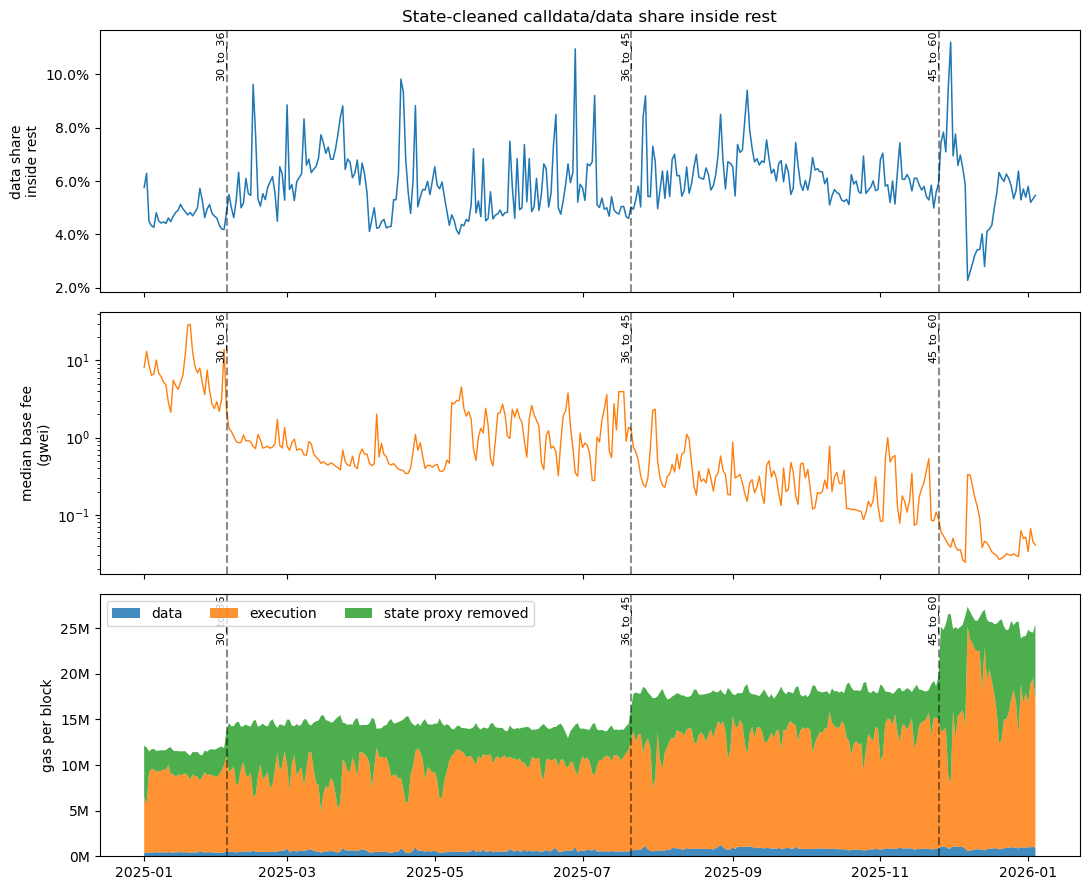

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(daily["date"], daily["data_share_rest"], linewidth=1.1)
axes[0].set_ylabel("data share\ninside rest")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title("State-cleaned calldata/data share inside rest")

axes[1].plot(daily["date"], daily["median_base_fee_per_gas"] / 1e9, linewidth=1.0, color="tab:orange")
axes[1].set_ylabel("median base fee\n(gwei)")
axes[1].set_yscale("log")

axes[2].stackplot(
    daily["date"],
    daily["data_gas_current"] / daily["block_count"],
    daily["execution_gas_state_cleaned_clipped"] / daily["block_count"],
    daily["current_state_inventory_delta_gas_proxy"] / daily["block_count"],
    labels=["data", "execution", "state proxy removed"],
    alpha=0.85,
)
axes[2].set_ylabel("gas per block")
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _pos: f"{x / 1e6:.0f}M"))
axes[2].legend(loc="upper left", ncol=3)

for ax in axes:
    for event in EVENTS:
        ax.axvline(event["date"], linestyle="--", color="black", alpha=0.45)
        ax.text(event["date"], ax.get_ylim()[1], event["event"], rotation=90, va="top", ha="right", fontsize=8)

axes[-1].set_xlabel("")
fig.tight_layout()
plot_path = PLOTS_DIR / "gas_limit_data_share_event_study_2025.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plot_path


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/gas_limit_data_share_event_eta_2025.png')

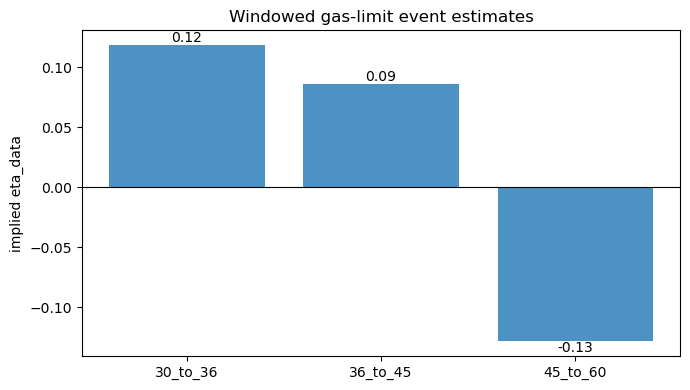

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = event_estimates.copy()
ax.axhline(0, color="black", linewidth=0.8)
ax.bar(plot_df["event"], plot_df["implied_eta_data"], color="tab:blue", alpha=0.8)
ax.set_ylabel("implied eta_data")
ax.set_title("Windowed gas-limit event estimates")
for idx, row in plot_df.iterrows():
    if np.isfinite(row["implied_eta_data"]):
        ax.text(idx, row["implied_eta_data"], f"{row['implied_eta_data']:.2f}", ha="center", va="bottom" if row["implied_eta_data"] >= 0 else "top")
fig.tight_layout()
plot_path = PLOTS_DIR / "gas_limit_data_share_event_eta_2025.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plot_path


## How To Read This

- Positive `eta_data` means data share rose when common blockspace price fell.
- Negative `eta_data` means execution expanded more than data in that window.
- The EIP-7623 notebook remains the cleaner calldata-only price shock.
- This gas-limit notebook is the common-price/capacity-shock complement.
- If the gas-limit and EIP-7623 estimates overlap, that supports using the
  overlap as the central `eta_data` range. If they disagree, keep the broad
  sweep.
